# So sánh 3 kiến trúc — YOLOv11 vs Faster R-CNN vs RetinaNet

Chạy sau khi cả 3 notebook train đã xong (mỗi cái tự lưu kết quả vào `comparison_results.json` trên Drive). Notebook này chỉ đọc lên và tổng hợp — không train gì thêm.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_JSON = '/content/drive/MyDrive/UIT/graduate_project/checkpoints/comparison_results.json'

with open(RESULTS_JSON) as f:
    results = json.load(f)

missing = [m for m in ['YOLOv11', 'Faster R-CNN', 'RetinaNet'] if m not in results]
if missing:
    print(f"[CẢNH BÁO] Chưa có kết quả cho: {missing} — chạy notebook train tương ứng trước.")

df = pd.DataFrame(results).T
df


Mounted at /content/drive


,mAP50,mAP50_95,mAP75,AP_small,AP_medium,AP_large,AR_max100,AR_small,AR_medium,AR_large,...,FN,best_epoch,total_epochs_run,fps,inference_ms,n_params,n_params_millions,total_train_time_min,peak_gpu_mem_gb,eval_split
YOLOv11,0.990001,0.882526,0.976117,-1.0,0.077369,0.882527,0.913178,-1.0,0.128571,0.913201,...,443,80,95,100.453917,9.954813,9413187,9.41,227.27,4.18,test (19200 anh)
Faster R-CNN,0.98905,0.798877,0.93048,-1.0,0.0,0.798898,0.83782,-1.0,0.0,0.837845,...,2020,3,9,37.622488,26.579847,41299161,41.3,124.09,32.36,test (19200 anh)
RetinaNet,0.980773,0.735573,0.867766,-1.0,0.0,0.735591,0.788662,-1.0,0.0,0.788685,...,4840,3,9,39.330253,25.42572,32168694,32.17,123.41,27.79,test (19200 anh)


## Biểu đồ so sánh

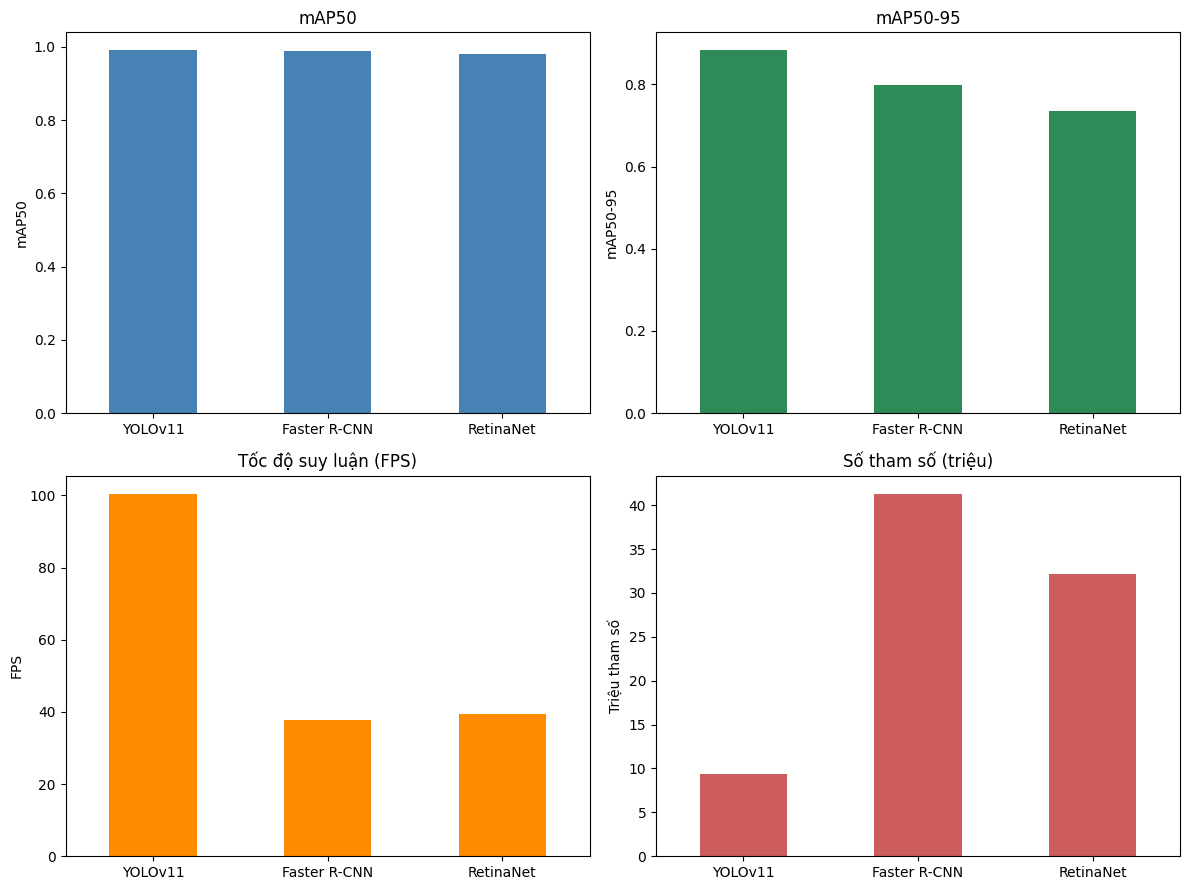

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

df['mAP50'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('mAP50')
axes[0, 0].set_ylabel('mAP50')

df['mAP50_95'].plot(kind='bar', ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('mAP50-95')
axes[0, 1].set_ylabel('mAP50-95')

df['fps'].plot(kind='bar', ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Tốc độ suy luận (FPS)')
axes[1, 0].set_ylabel('FPS')

df['n_params_millions'].plot(kind='bar', ax=axes[1, 1], color='indianred')
axes[1, 1].set_title('Số tham số (triệu)')
axes[1, 1].set_ylabel('Triệu tham số')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UIT/graduate_project/checkpoints/comparison_chart.png')
plt.show()
